In [1]:
import pandas as pd
import numpy as np

# Load Titanic dataset from public repository
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic_df = pd.read_csv(url)

print("Dataset Shape (rows, cols):", titanic_df.shape)
print("\nFirst 3 rows of raw dataset:")
print(titanic_df.head(3))

# Count missing values
missing_counts = titanic_df.isnull().sum()
print("\nMissing Values per column:\n", missing_counts)

Dataset Shape (rows, cols): (891, 12)

First 3 rows of raw dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  

Missing Values per column:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: in

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Select numerical features
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
X = titanic_df[features]
# Apply Min-Max Scaling (Normalization)
min_max_scaler = MinMaxScaler()
X_normalized = min_max_scaler.fit_transform(X)

print("Normalized Range Boundaries (Min/Max):",
      X_normalized.min(), "to", X_normalized.max())

# Apply Standardization
standard_scaler = StandardScaler()
X_standardized = standard_scaler.fit_transform(X)

print("Standardized Mean (approx 0):",
      round(X_standardized.mean(),4))
print("Standardized Std Dev (approx 1):",
      round(X_standardized.std(),4))

Normalized Range Boundaries (Min/Max): nan to nan
Standardized Mean (approx 0): nan
Standardized Std Dev (approx 1): nan


In [3]:
# Handle missing values using Median and Most Frequent strategies

# Numerical Columns
num_cols = ['Age', 'Fare']

median_imputer = SimpleImputer(strategy='median')
titanic_df[num_cols] = median_imputer.fit_transform(titanic_df[num_cols])

# Categorical Columns
cat_cols = ['Embarked']

mode_imputer = SimpleImputer(strategy='most_frequent')
titanic_df[cat_cols] = mode_imputer.fit_transform(titanic_df[cat_cols])

# Replace missing Cabin values with 'Unknown'
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('Unknown')

print("\nMissing values after imputation:")
print(titanic_df.isnull().sum())


Missing values after imputation:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [4]:
from sklearn.preprocessing import PowerTransformer

# Evaluate skewness of Fare column
original_skew = titanic_df['Fare'].skew()

print("Original skewness coefficient of 'Fare':",
      round(original_skew,4))

# Apply Yeo-Johnson Power Transformation
power_transformer = PowerTransformer(method='yeo-johnson')

fare_transformed = power_transformer.fit_transform(
    titanic_df[['Fare']]
)

# New skewness
transformed_skew = pd.Series(
    fare_transformed.flatten()
).skew()

print("Skewness coefficient after Power Transformation:",
      round(transformed_skew,4))

Original skewness coefficient of 'Fare': 4.7873
Skewness coefficient after Power Transformation: -0.0403


In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical column
label_encoder = LabelEncoder()

titanic_df['Sex'] = label_encoder.fit_transform(
    titanic_df['Sex']
)

# Create processed dataset
processed_titanic_df = pd.DataFrame(
    data=X_standardized,
    columns=features
)

processed_titanic_df['Sex'] = titanic_df['Sex']
processed_titanic_df['Survived'] = titanic_df['Survived']

# Export processed dataset
processed_titanic_df.to_csv(
    "processed_titanic.csv",
    index=False
)

print("Processed Titanic dataset exported successfully to 'processed_titanic.csv'. Shape:",
      processed_titanic_df.shape)

Processed Titanic dataset exported successfully to 'processed_titanic.csv'. Shape: (891, 7)


In [6]:
#task-2
from sklearn.preprocessing import StandardScaler

# Select numerical features
titanic_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

X_titanic = titanic_df[titanic_features]

# Scale features
scaler = StandardScaler()
X_titanic_scaled = scaler.fit_transform(X_titanic)

print("Standardized features shape:", X_titanic_scaled.shape)

Standardized features shape: (891, 6)


In [7]:
from sklearn.decomposition import PCA

# Apply PCA to preserve 90% variance
pca_90 = PCA(n_components=0.90, random_state=42)
X_pca_90 = pca_90.fit_transform(X_titanic_scaled)

print("Original dimensions count:", X_titanic_scaled.shape[1])
print("Reduced dimensions count (to preserve 90% variance):", X_pca_90.shape[1])

Original dimensions count: 6
Reduced dimensions count (to preserve 90% variance): 5


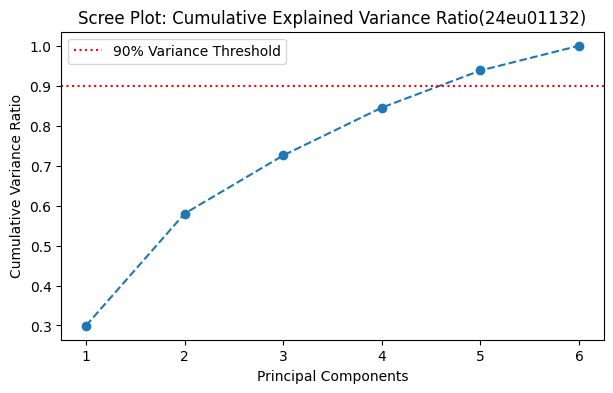

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Fit full PCA
pca_full = PCA(random_state=42)
pca_full.fit(X_titanic_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='o',
         linestyle='--')

plt.axhline(y=0.90,
            color='r',
            linestyle=':',
            label='90% Variance Threshold')

plt.title("Scree Plot: Cumulative Explained Variance Ratio(24eu01132)")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance Ratio")
plt.legend()
plt.show()

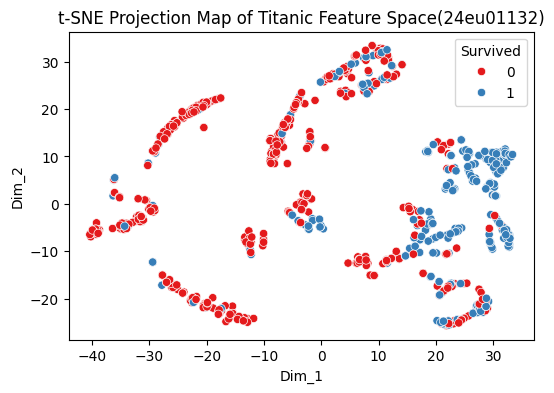

In [9]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, perplexity=30, random_state=42)

X_tsne = tsne.fit_transform(X_titanic_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=['Dim_1', 'Dim_2'])
tsne_df['Survived'] = titanic_df['Survived']

plt.figure(figsize=(6,4))

sns.scatterplot(data=tsne_df,
                x='Dim_1',
                y='Dim_2',
                hue='Survived',
                palette='Set1')

plt.title("t-SNE Projection Map of Titanic Feature Space(24eu01132)")
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

y = titanic_df['Survived']

# Using all scaled features
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_titanic_scaled, y, test_size=0.3, random_state=42
)

lr_raw = LogisticRegression(max_iter=1000)
lr_raw.fit(X_train_raw, y_train)

acc_raw = accuracy_score(y_test, lr_raw.predict(X_test_raw))

# Using PCA features
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca_90, y, test_size=0.3, random_state=42
)

lr_pca = LogisticRegression(max_iter=1000)
lr_pca.fit(X_train_pca, y_train)

acc_pca = accuracy_score(y_test, lr_pca.predict(X_test_pca))

print(f"Accuracy using all scaled features: {acc_raw*100:.2f}%")
print(f"Accuracy using {X_pca_90.shape[1]} PCA components: {acc_pca*100:.2f}%")

Accuracy using all scaled features: 81.34%
Accuracy using 5 PCA components: 80.22%


In [11]:
#ask3
from sklearn.feature_selection import SelectKBest, f_classif

# Rank and select the top 4 features using SelectKBest
selector = SelectKBest(score_func=f_classif, k=4)
selector.fit(X_titanic_scaled, titanic_df['Survived'])

# Build a summary DataFrame of feature scores
anova_scores = pd.DataFrame({
    'Feature': titanic_features,
    'F-Score': selector.scores_
}).sort_values(by='F-Score', ascending=False)

print("ANOVA F-Test Scores:\n", anova_scores)

ANOVA F-Test Scores:
   Feature     F-Score
1     Sex  372.405724
0  Pclass  115.031272
5    Fare   63.030764
4   Parch    5.963464
2     Age    3.761528
3   SibSp    1.110572


In [15]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Run RFE using Logistic Regression
estimator = LogisticRegression(max_iter=1000)

rfe = RFE(estimator=estimator, n_features_to_select=4)

rfe.fit(X_titanic_scaled, titanic_df['Survived'])

# Display ranking
rfe_support = pd.DataFrame({
    'Feature': titanic_features,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values(by='Ranking')

print("RFE Selected Features:\n", rfe_support)

RFE Selected Features:
   Feature  Selected  Ranking
0  Pclass      True        1
1     Sex      True        1
2     Age      True        1
3   SibSp      True        1
5    Fare     False        2
4   Parch     False        3


In [16]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression with L1 Regularization
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.5,
    random_state=42
)

lasso.fit(X_titanic_scaled, titanic_df['Survived'])

lasso_coefs = pd.DataFrame({
    'Feature': titanic_features,
    'Coefficient': lasso.coef_[0]
}).sort_values(by='Coefficient',
               key=abs,
               ascending=False)

print("Lasso Regularization Coefficients:\n", lasso_coefs)

Lasso Regularization Coefficients:
   Feature  Coefficient
1     Sex    -1.285546
0  Pclass    -0.880807
2     Age    -0.475790
3   SibSp    -0.349971
5    Fare     0.123079
4   Parch    -0.068232


Random Forest Feature Importances:
   Feature  Importance
5    Fare    0.296772
1     Sex    0.268796
2     Age    0.264768
0  Pclass    0.083184
3   SibSp    0.050660
4   Parch    0.035821


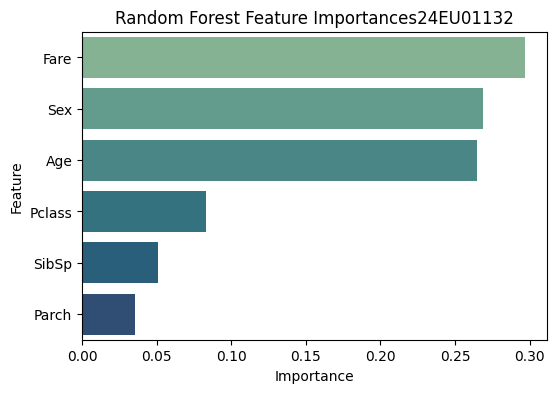

In [20]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Train Random Forest
rf = RandomForestClassifier(random_state=42)

rf.fit(X_titanic, titanic_df['Survived'])

# Feature Importances
importances = pd.DataFrame({
    'Feature': titanic_features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Random Forest Feature Importances:\n", importances)

plt.figure(figsize=(6,4))

sns.barplot(
    data=importances,
    x='Importance',
    y='Feature',
    palette='crest'
)

plt.title("Random Forest Feature Importances24EU01132")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_titanic,
    titanic_df['Survived'],
    test_size=0.3,
    random_state=42
)

# Model 1: All features
rf_full = RandomForestClassifier(random_state=42)

rf_full.fit(X_train, y_train)

preds_full = rf_full.predict(X_test)

# Model 2: Top 4 features
top_4_cols = importances.head(4)['Feature'].tolist()

X_train_sub = X_train[top_4_cols]
X_test_sub = X_test[top_4_cols]

rf_sub = RandomForestClassifier(random_state=42)

rf_sub.fit(X_train_sub, y_train)

preds_sub = rf_sub.predict(X_test_sub)

print("--- CLASSIFICATION REPORT: ALL FEATURES ---")
print(classification_report(y_test, preds_full))

print("\n--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 Features) ---")
print(classification_report(y_test, preds_sub))

--- CLASSIFICATION REPORT: ALL FEATURES ---
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       157
           1       0.78      0.71      0.75       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268


--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 Features) ---
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       157
           1       0.78      0.69      0.73       111

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268

